In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme(color_codes=True)

# Dataset :
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**About the Dataset:**  
The IBM Telco Customer Churn dataset contains information about a telecom company's customers.  
The goal is to predict whether a customer will churn (leave the service) based on features like contract type, monthly charges, tenure, internet service, and payment method.

**Target Column:** `Churn` — Yes (1) / No (0)

In [40]:

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Exploratory Data Analysis

In [41]:
# Shape and basic info
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [42]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


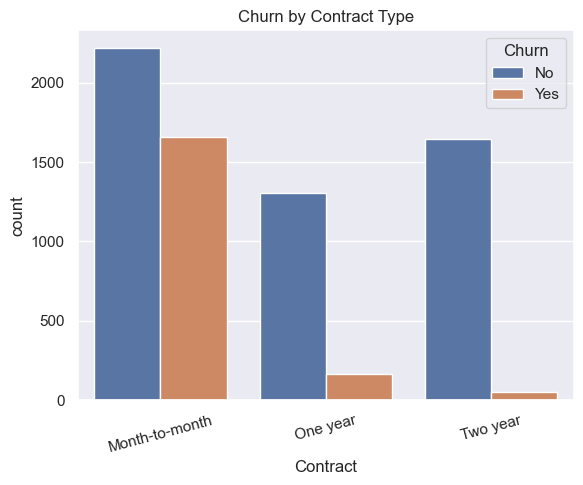

In [43]:
# Churn distribution
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

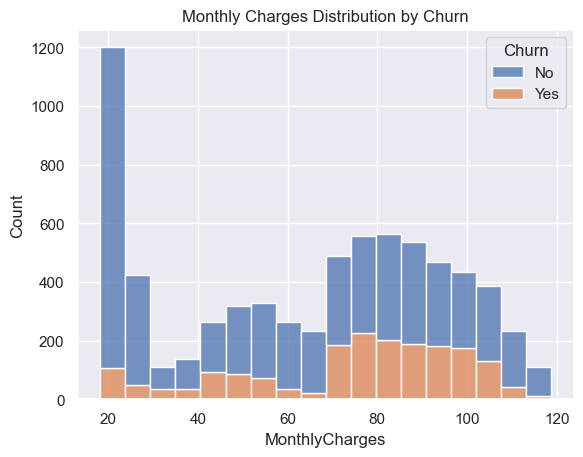

In [44]:
# Monthly Charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack')
plt.title('Monthly Charges Distribution by Churn')
plt.show()

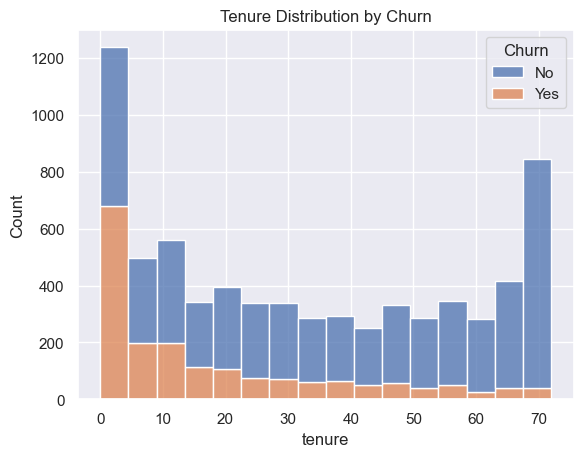

In [45]:
# Tenure distribution 
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.title('Tenure Distribution by Churn')
plt.show()

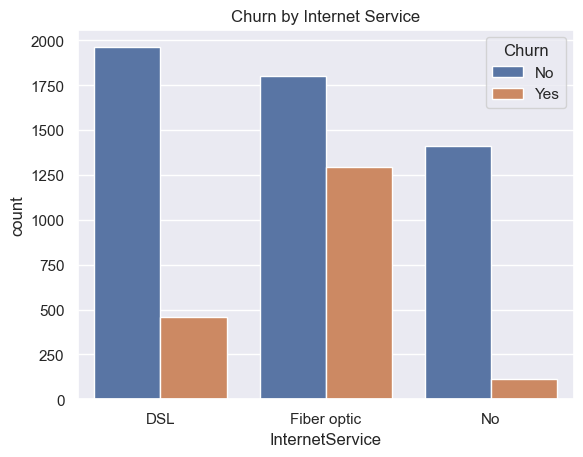

In [46]:
# Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

# Data Preprocessing

In [47]:
# Check null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [48]:
# TotalCharges has spaces instead of NaN — fix it
df_copy = df.copy(deep=True)
df_copy['TotalCharges'] = pd.to_numeric(df_copy['TotalCharges'], errors='coerce')

# Showing the Count of NANs after conversion
print(df_copy.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [49]:
# Fill NaN TotalCharges with median
df_copy['TotalCharges'].fillna(df_copy['TotalCharges'].median(), inplace=True)

# Drop customerID — not useful for prediction
df_copy.drop('customerID', axis=1, inplace=True)

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_copy[col] = df_copy[col].map({'Yes': 1, 'No': 0})

# Encode gender
df_copy['gender'] = df_copy['gender'].map({'Male': 1, 'Female': 0})

# ✅ Replace Label Encoding with One-Hot Encoding
df_copy = pd.get_dummies(df_copy, drop_first=True)

print("Encoding complete. Shape:", df_copy.shape)
df_copy.head()

Encoding complete. Shape: (7043, 31)


C:\Users\shish\AppData\Local\Temp\ipykernel_2168\845884426.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['TotalCharges'].fillna(df_copy['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


# Check if the class label is balanced or not

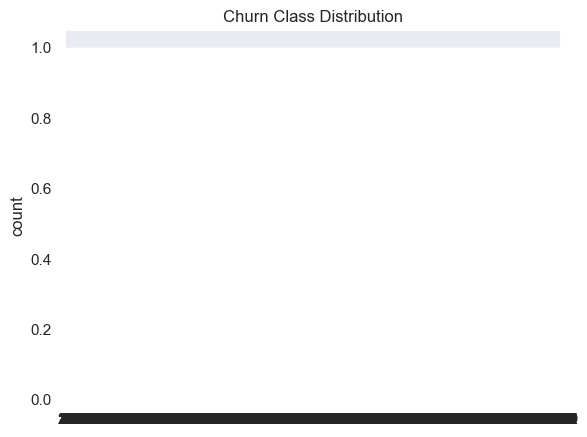

Churn
0    5174
1    1869
Name: count, dtype: int64


In [50]:
sns.countplot(df_copy['Churn'])
plt.title('Churn Class Distribution')
plt.show()
print(df_copy.Churn.value_counts())

# Do Oversampling Minority Class to Balance the class label

In [51]:
from sklearn.utils import resample

majority = df_copy[df_copy['Churn'] == 0]
minority = df_copy[df_copy['Churn'] == 1]

minority_updated = resample(minority, n_samples=len(majority), random_state=0)
df2 = pd.concat([minority_updated, majority])

print("After oversampling:")
print(df2.Churn.value_counts())

After oversampling:
Churn
1    5174
0    5174
Name: count, dtype: int64


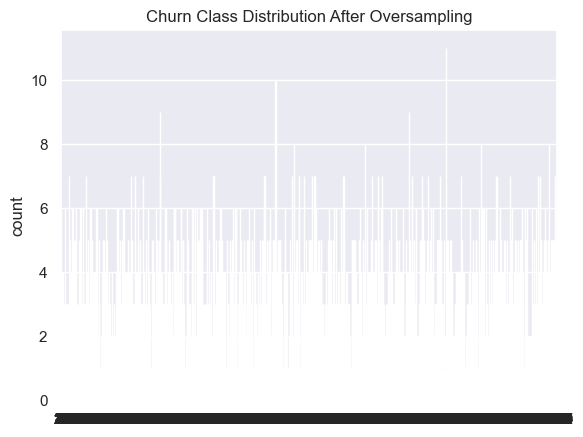

Churn
1    5174
0    5174
Name: count, dtype: int64


In [52]:
sns.countplot(df2['Churn'])
plt.title('Churn Class Distribution After Oversampling')
plt.show()
print(df2.Churn.value_counts())

# Check the Outlier using Boxplot

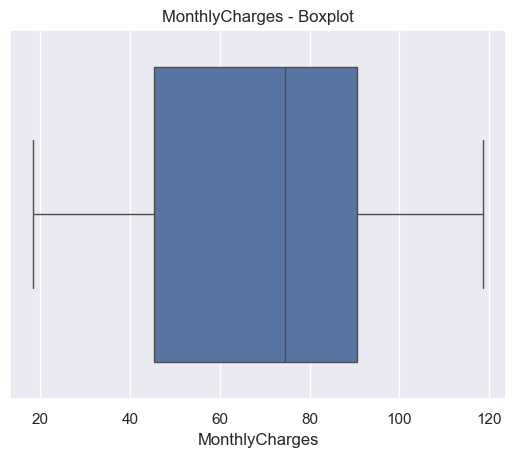

In [53]:
sns.boxplot(x=df2['MonthlyCharges'])
plt.title('MonthlyCharges - Boxplot')
plt.show()

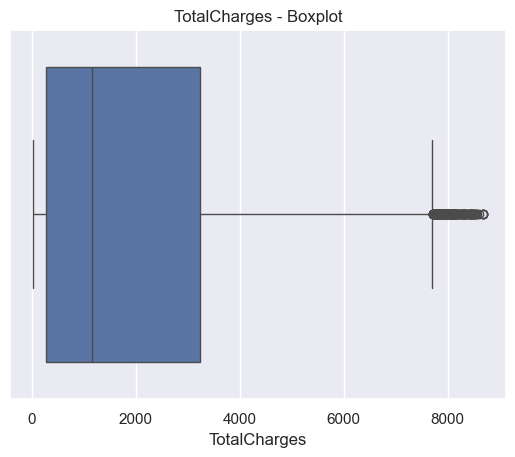

In [54]:
sns.boxplot(x=df2['TotalCharges'])
plt.title('TotalCharges - Boxplot')
plt.show()

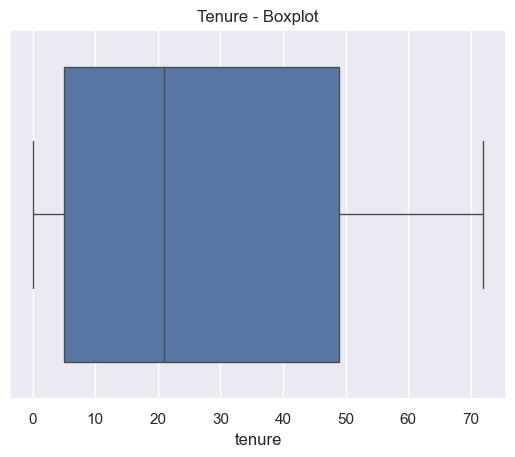

In [55]:
sns.boxplot(x=df2['tenure'])
plt.title('Tenure - Boxplot')
plt.show()

# Remove Outlier using Z-Score

In [56]:
import scipy.stats as stats

numeric_df = df2.select_dtypes(include=[np.number])
z = np.abs(stats.zscore(numeric_df, nan_policy='omit'))
z = np.nan_to_num(z, nan=0.0)

data_clean = df2[(z < 3).all(axis=1)]
print("Shape after outlier removal:", data_clean.shape)

Shape after outlier removal: (9371, 31)


# Heatmap Data Correlation

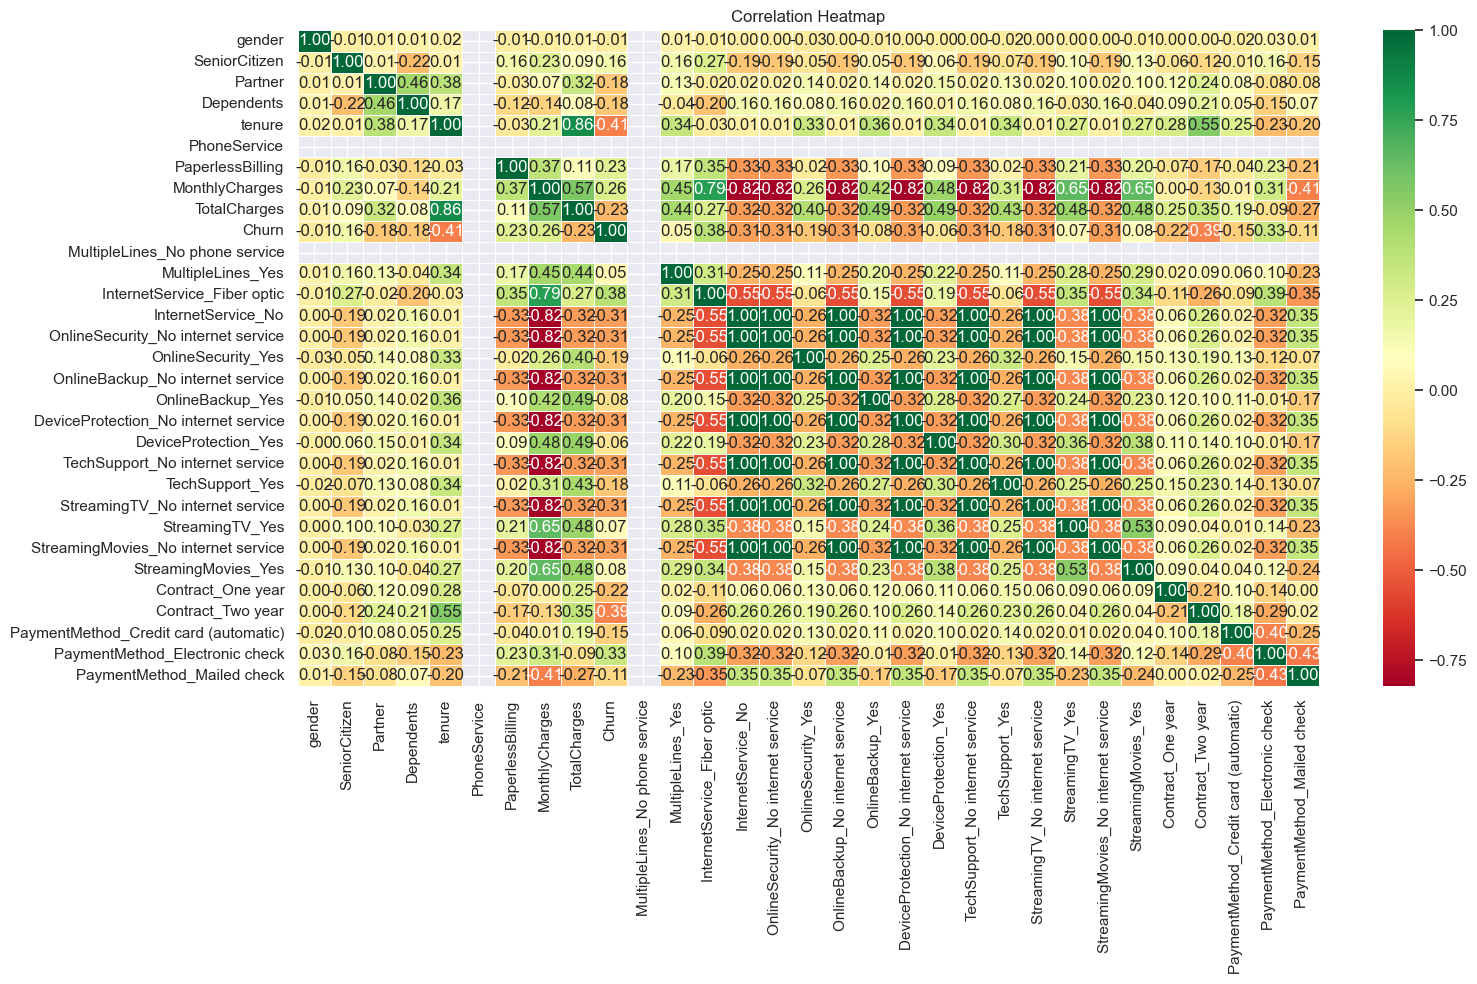

In [57]:
plt.figure(figsize=(16, 10))
sns.heatmap(data_clean.corr(), annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [58]:
# Print top correlated features with Churn
print("Top features correlated with Churn:")
print(data_clean.corr()['Churn'].drop('Churn').sort_values(ascending=False))

Top features correlated with Churn:
InternetService_Fiber optic              0.381900
PaymentMethod_Electronic check           0.327969
MonthlyCharges                           0.262362
PaperlessBilling                         0.231845
SeniorCitizen                            0.158101
StreamingMovies_Yes                      0.076804
StreamingTV_Yes                          0.073759
MultipleLines_Yes                        0.045476
gender                                  -0.013980
DeviceProtection_Yes                    -0.058558
OnlineBackup_Yes                        -0.083102
PaymentMethod_Mailed check              -0.111330
PaymentMethod_Credit card (automatic)   -0.151971
Partner                                 -0.175505
Dependents                              -0.179880
TechSupport_Yes                         -0.182990
OnlineSecurity_Yes                      -0.185102
Contract_One year                       -0.215456
TotalCharges                            -0.233586
InternetServic

# Machine Learning Model Building

In [59]:
X = data_clean.drop('Churn', axis=1)
y = data_clean['Churn']

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Split first (GOOD ✅)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Apply SMOTE only on training data (CORRECT ✅)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (7544, 30)
Test size:  (1875, 30)


# Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=0)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print('F-1 Score      :', f1_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score   :', recall_score(y_test, y_pred))

Accuracy Score : 77.87 %
F-1 Score      : 0.7885888945491595
Precision Score: 0.7588235294117647
Recall Score   : 0.8207847295864263


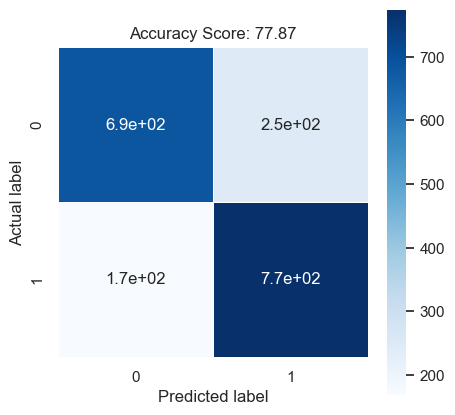

In [61]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(lr.score(X_test, y_test)*100, 2)))
plt.show()

# Adaboost Algorithm

In [62]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=0)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print('F-1 Score      :', f1_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score   :', recall_score(y_test, y_pred))

Accuracy Score : 78.77 %
F-1 Score      : 0.7961065573770492
Precision Score: 0.7700693756194251
Recall Score   : 0.823966065747614


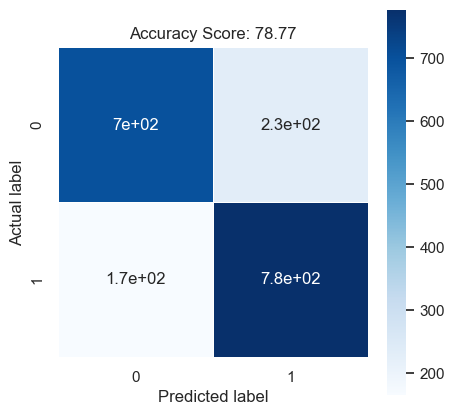

In [63]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(ada.score(X_test, y_test)*100, 2)))
plt.show()

# K Nearest Neighbour

In [64]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print('F-1 Score      :', f1_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score   :', recall_score(y_test, y_pred))

Accuracy Score : 77.07 %
F-1 Score      : 0.7862823061630219
Precision Score: 0.7399438727782974
Recall Score   : 0.83881230116649


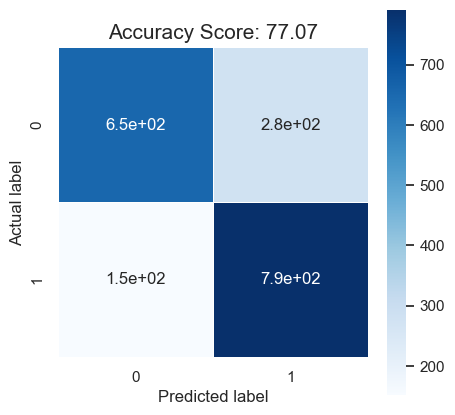

In [65]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(knn.score(X_test, y_test)*100, 2)), size=15)
plt.show()

# Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=0)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print('F-1 Score      :', f1_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score   :', recall_score(y_test, y_pred))

Accuracy Score : 90.13 %
F-1 Score      : 0.9070818684078352
Precision Score: 0.8616412213740458
Recall Score   : 0.9575821845174973


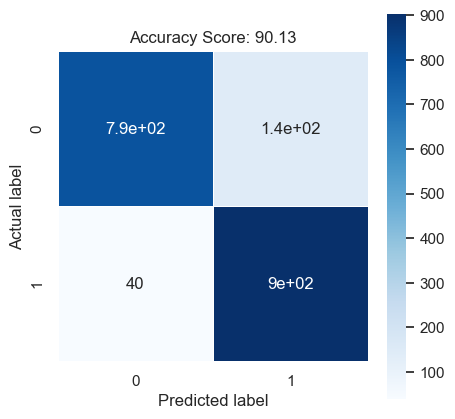

In [67]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
sns.heatmap(data=cm, linewidths=.5, annot=True, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}'.format(round(rfc.score(X_test, y_test)*100, 2)))
plt.show()

# Model Accuracy Comparison

                 Model  Accuracy (%)
0        Random Forest         90.13
1             AdaBoost         78.77
2  Logistic Regression         77.87
3                  KNN         77.07


C:\Users\shish\AppData\Local\Temp\ipykernel_2168\2253733083.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='Accuracy (%)', palette='Blues_d')


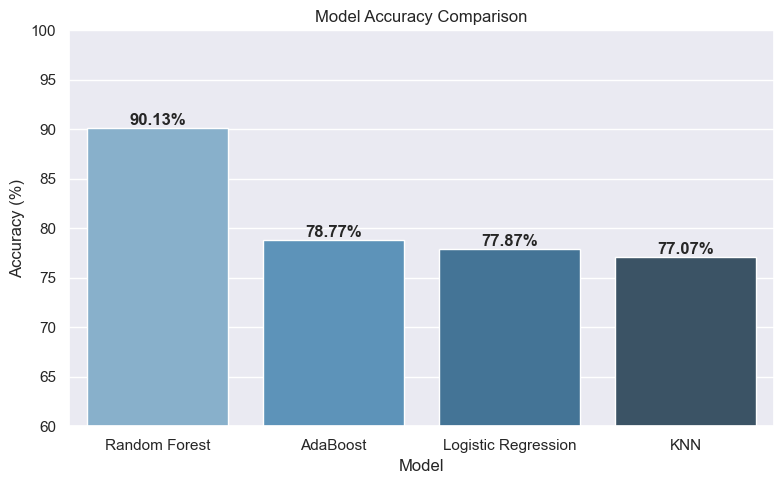

In [68]:
models     = ['Logistic Regression', 'AdaBoost', 'KNN', 'Random Forest']
classifiers = [lr, ada, knn, rfc]
accuracies  = [round(clf.score(X_test, y_test)*100, 2) for clf in classifiers]

comparison_df = pd.DataFrame({'Model': models, 'Accuracy (%)': accuracies})
comparison_df = comparison_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='Model', y='Accuracy (%)', palette='Blues_d')
plt.title('Model Accuracy Comparison')
plt.ylim(60, 100)
for i, v in enumerate(comparison_df['Accuracy (%)']):
    plt.text(i, v + 0.3, str(v) + '%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Export the Best Model
Let's export the Random Forest model and the column names so our Flask app can process new incoming data accurately.

In [69]:
import pickle

# Ensure rfc exists (if the Random Forest training cell was not run)
if 'rfc' not in globals():
    from sklearn.ensemble import RandomForestClassifier
    rfc = RandomForestClassifier(n_estimators=100, random_state=0)
    rfc.fit(X_train, y_train)

# Save the Random Forest Model
with open('model.pkl', 'wb') as f:
    pickle.dump(rfc, f)

# Save feature columns to match Flask app inputs
feature_columns = list(X.columns) if 'X' in globals() else list(X_train.columns)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Model and columns saved successfully!")

Model and columns saved successfully!
